# EfficientNetV2 Model for RAF-DB Emotion Recognition


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import pandas as pd
import numpy as np
from PIL import Image
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Constants for RAF-DB (7 emotions)
EMOTIONS = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Anger', 'Neutral']
NUM_CLASSES = len(EMOTIONS)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-4
IMG_SIZE = 224

In [4]:
# Early stopping class
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [5]:
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image

class RAFDBDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):

        self.root_dir = Path(root_dir) / split
        self.transform = transform
        self.images = []
        self.labels = []

        # RAF-DB has 7 emotion classes (1 → 7)
        for label in range(1, 8):

            class_folder = self.root_dir / str(label)

            if not class_folder.exists():
                print(f"Missing folder: {class_folder}")
                continue

            # Load ALL aligned images
            img_files = list(class_folder.glob('*_aligned.jpg'))

            for img_path in img_files:
                self.images.append(img_path)
                self.labels.append(label - 1)  # make 0–6

        print(f"Loaded {len(self.images)} images for {split} split")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = self.images[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
# Data transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
import kagglehub
path = kagglehub.dataset_download("shuvoalok/raf-db-dataset", output_dir='/home/jupyter-iec2024iot08/qiocas/CS231/datasets')

print("Path to dataset files:", path)

data_dir = os.path.join(path, "DATASET")

Path to dataset files: /home/jupyter-iec2024iot08/qiocas/CS231/datasets


In [9]:
print("Loading RAF-DB datasets...")
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader
import numpy as np
from collections import Counter

# Dataset train có augmentation
full_train_aug = RAFDBDataset(data_dir, split='train', transform=train_transform)

# Dataset train nhưng dùng transform sạch cho validation
full_train_clean = RAFDBDataset(data_dir, split='train', transform=test_transform)

labels = np.array(full_train_clean.labels)
indices = np.arange(len(labels))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_dataset = Subset(full_train_aug, train_idx)
val_dataset = Subset(full_train_clean, val_idx)

test_dataset = RAFDBDataset(data_dir, split='test', transform=test_transform)

print("Train distribution:", Counter(labels[train_idx]))
print("Val distribution:", Counter(labels[val_idx]))

Loading RAF-DB datasets...
Loaded 12271 images for train split
Loaded 12271 images for train split
Loaded 3068 images for test split
Train distribution: Counter({np.int64(3): 3817, np.int64(6): 2019, np.int64(4): 1585, np.int64(0): 1032, np.int64(2): 574, np.int64(5): 564, np.int64(1): 225})
Val distribution: Counter({np.int64(3): 955, np.int64(6): 505, np.int64(4): 397, np.int64(0): 258, np.int64(2): 143, np.int64(5): 141, np.int64(1): 56})


In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [11]:
# Initialize EfficientNetV2 model
print("\nInitializing EfficientNetV2 model...")
efficientnet = models.efficientnet_v2_s(pretrained=True)
num_features = efficientnet.classifier[1].in_features
efficientnet.classifier[1] = nn.Linear(num_features, NUM_CLASSES)
efficientnet = efficientnet.to(device)


Initializing EfficientNetV2 model...


In [12]:
# show the model architecture
print(efficientnet)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [13]:
# Training function with early stopping
def train_efficientnet(model, model_name, train_loader, val_loader, test_loader, epochs=EPOCHS, patience=5):
    print(f"\n{'='*50}")
    print(f"Training {model_name} on RAF-DB with Early Stopping (patience={patience})")
    print('='*50)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
    
    # Initialize early stopping
    early_stopping = EarlyStopping(patience=patience, min_delta=0.01)
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    stopped_epoch = epochs
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
        for inputs, labels in train_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            train_pbar.set_postfix({'loss': running_loss/(len(train_pbar)), 
                                   'acc': 100.*correct/total})
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        current_lr = optimizer.param_groups[0]["lr"]

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]')
            for inputs, labels in val_pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
                val_pbar.set_postfix({'loss': val_loss/(len(val_pbar)), 
                                     'acc': 100.*correct/total})
        
        val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        scheduler.step(val_loss)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name}_rafdb.pth')
            print(f"✓ New best model saved with accuracy: {val_acc:.2f}%")
        
        print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | LR: {current_lr:.6f}')
        
        # Check early stopping
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
            stopped_epoch = epoch + 1
            break
    
    # Final evaluation with best model
    print(f"\n📊 Loading best model for final evaluation...")
    model.load_state_dict(torch.load(f'best_{model_name}_rafdb.pth'))
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return {
        'model_name': model_name,
        'train_losses': train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc,
        'predictions': all_preds,
        'true_labels': all_labels,
        'stopped_epoch': stopped_epoch
    }


In [14]:
# Train EfficientNetV2 on RAF-DB
print("\n" + "="*60)
print("STARTING EFFICIENTNETV2 TRAINING ON RAF-DB")
print("="*60)

efficientnet_results = train_efficientnet(efficientnet, 'EfficientNetV2_RAFDB', train_loader, val_loader, test_loader, patience=5)


STARTING EFFICIENTNETV2 TRAINING ON RAF-DB

Training EfficientNetV2_RAFDB on RAF-DB with Early Stopping (patience=5)


Epoch 1/20 [Train]:   0%|          | 0/307 [00:00<?, ?it/s]

Epoch 1/20 [Val]: 100%|██████████| 77/77 [00:02<00:00, 30.25it/s, loss=0.692, acc=76.5]


✓ New best model saved with accuracy: 76.54%
Epoch 1: Train Loss: 1.1239, Train Acc: 59.02% | Val Loss: 0.6920, Val Acc: 76.54% | LR: 0.000100


Epoch 2/20 [Val]: 100%|██████████| 77/77 [00:02<00:00, 30.43it/s, loss=0.601, acc=79.3] 


...

Epoch 6: Train Loss: 0.1791, Train Acc: 93.73% | Val Loss: 0.6769, Val Acc: 80.65% | LR: 0.000100
EarlyStopping counter: 3 out of 5


Epoch 7/20 [Val]: 100%|██████████| 77/77 [00:02<00:00, 28.24it/s, loss=0.713, acc=80.6]


Epoch 7: Train Loss: 0.1392, Train Acc: 94.88% | Val Loss: 0.7134, Val Acc: 80.61% | LR: 0.000100
EarlyStopping counter: 4 out of 5


Epoch 8/20 [Val]: 100%|██████████| 77/77 [00:02<00:00, 28.17it/s, loss=0.672, acc=83.2] 


✓ New best model saved with accuracy: 83.22%
Epoch 8: Train Loss: 0.0800, Train Acc: 97.45% | Val Loss: 0.6719, Val Acc: 83.22% | LR: 0.000050
EarlyStopping counter: 5 out of 5

⚠️ Early stopping triggered at epoch 8

📊 Loading best model for final evaluation...


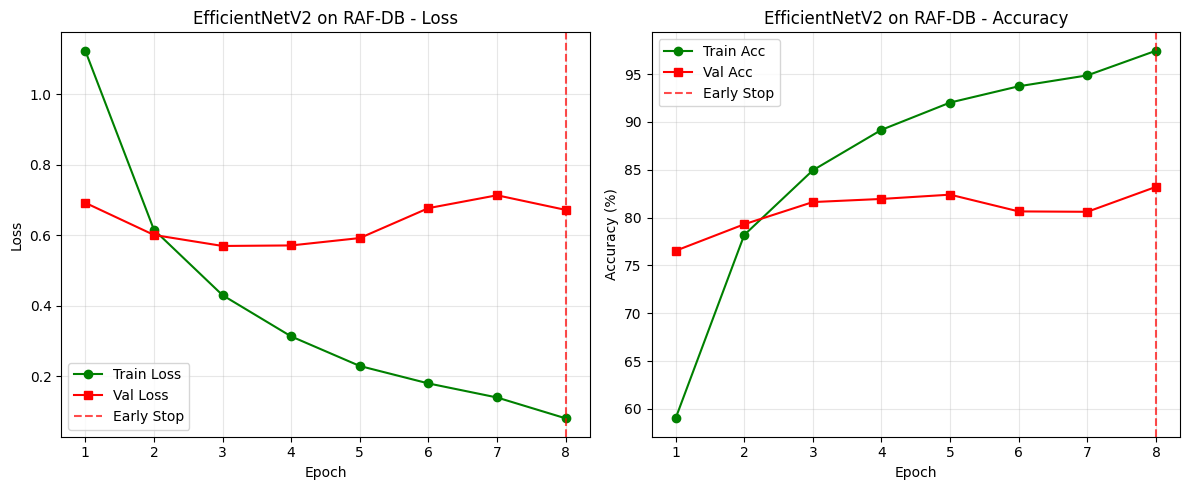

In [15]:
# Plotting results for EfficientNetV2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

epochs_range = range(1, len(efficientnet_results['train_losses']) + 1)

# Plot losses
axes[0].plot(epochs_range, efficientnet_results['train_losses'], label='Train Loss', marker='o', color='green')
axes[0].plot(epochs_range, efficientnet_results['val_losses'], label='Val Loss', marker='s', color='red')
axes[0].axvline(x=efficientnet_results['stopped_epoch'], color='red', linestyle='--', alpha=0.7, label='Early Stop')
axes[0].set_title(f'EfficientNetV2 on RAF-DB - Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot accuracies
axes[1].plot(epochs_range, efficientnet_results['train_accs'], label='Train Acc', marker='o', color='green')
axes[1].plot(epochs_range, efficientnet_results['val_accs'], label='Val Acc', marker='s', color='red')
axes[1].axvline(x=efficientnet_results['stopped_epoch'], color='red', linestyle='--', alpha=0.7, label='Early Stop')
axes[1].set_title('EfficientNetV2 on RAF-DB - Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('efficientnet_rafdb_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

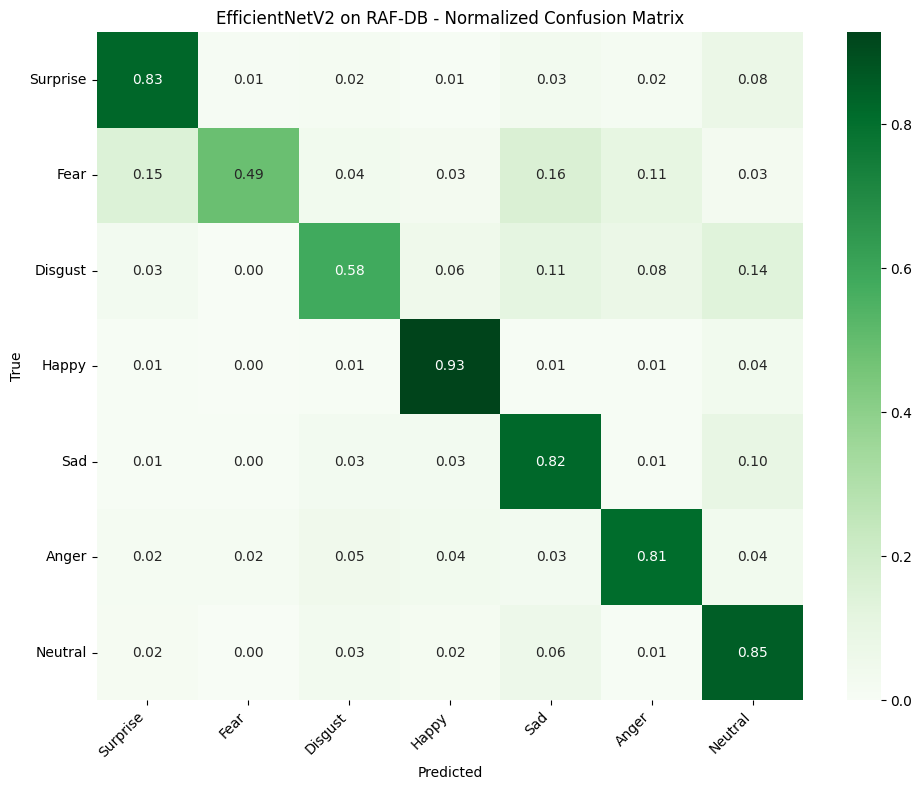

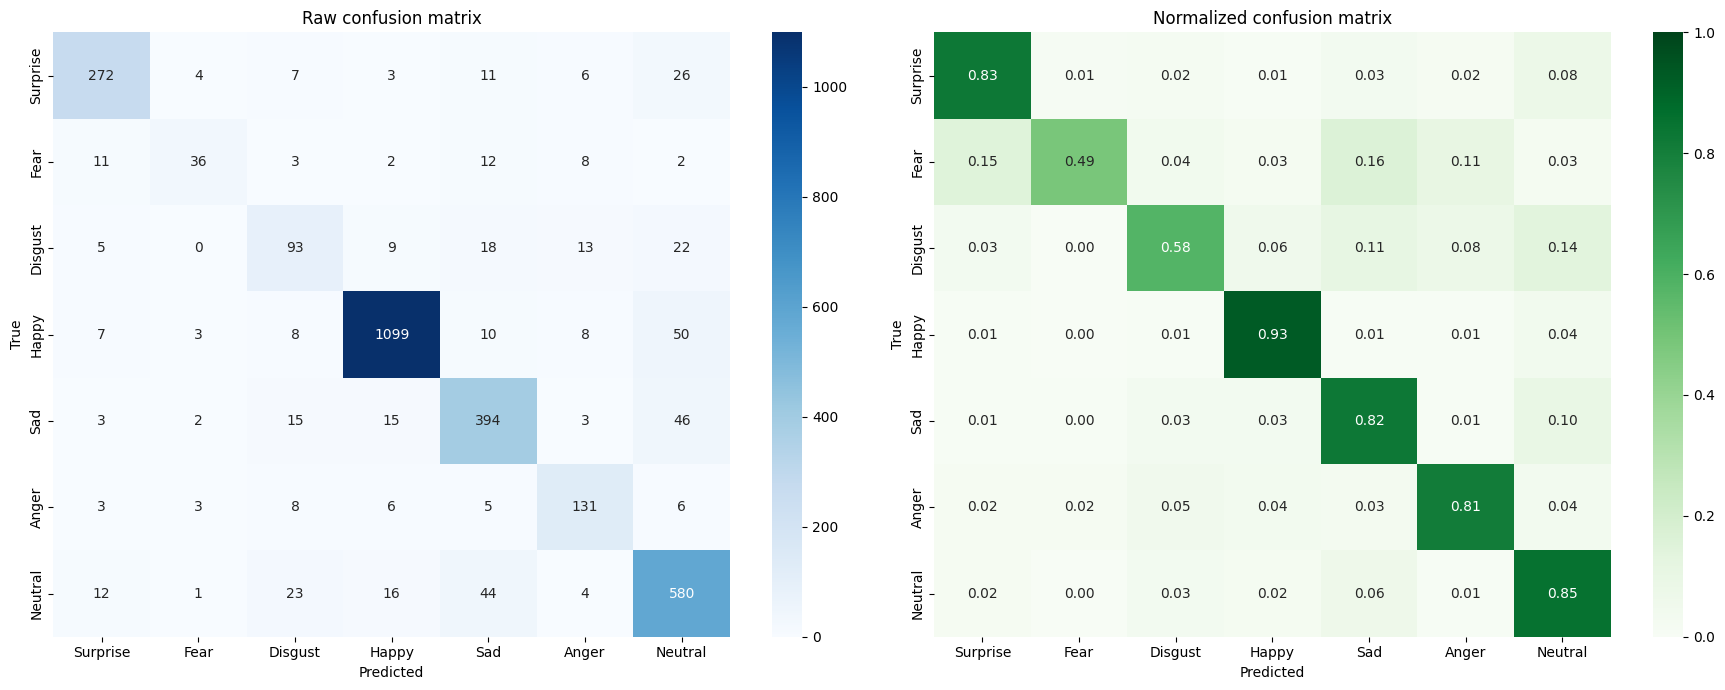

In [ ]:
cm = confusion_matrix(efficientnet_results['true_labels'], efficientnet_results['predictions'])
cm_norm = confusion_matrix(efficientnet_results['true_labels'], efficientnet_results['predictions'], normalize='true')

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax[0])
ax[0].set_title('Raw confusion matrix')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', vmin=0, vmax=1, xticklabels=EMOTIONS, yticklabels=EMOTIONS, ax=ax[1])
ax[1].set_title('Normalized confusion matrix')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('True')

plt.tight_layout()
plt.show()

In [17]:
# Classification report for EfficientNetV2
print("\n" + "="*60)
print("EFFICIENTNETV2 ON RAF-DB - CLASSIFICATION REPORT")
print("="*60)
print(classification_report(efficientnet_results['true_labels'], efficientnet_results['predictions'], 
                           target_names=EMOTIONS, zero_division=0, digits=4))

# Per-class performance analysis
print(f"\n📈 Detailed Analysis for EfficientNetV2 on RAF-DB:")
cm = confusion_matrix(efficientnet_results['true_labels'], efficientnet_results['predictions'])

# Calculate per-class accuracy
class_acc = cm.diagonal() / cm.sum(axis=1)
print(f"\n{'Emotion':<15} {'Accuracy':<15}")
print("-"*30)
for emotion, acc in zip(EMOTIONS, class_acc):
    print(f"{emotion:<15} {acc*100:.2f}%")

# Find easiest and hardest emotions
best_class_idx = np.argmax(class_acc)
worst_class_idx = np.argmin(class_acc)
print(f"\n✅ Best performing emotion: {EMOTIONS[best_class_idx]} ({class_acc[best_class_idx]*100:.2f}%)")
print(f"❌ Worst performing emotion: {EMOTIONS[worst_class_idx]} ({class_acc[worst_class_idx]*100:.2f}%)")

# Save results
print(f"\n📁 EfficientNetV2 on RAF-DB results saved")
print(f"   Best validation accuracy: {efficientnet_results['best_val_acc']:.2f}%")
print(f"   Stopped at epoch: {efficientnet_results['stopped_epoch']}")
print(f"   Total epochs trained: {len(efficientnet_results['train_accs'])}")


EFFICIENTNETV2 ON RAF-DB - CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Surprise     0.8690    0.8267    0.8474       329
        Fear     0.7347    0.4865    0.5854        74
     Disgust     0.5924    0.5813    0.5868       160
       Happy     0.9557    0.9274    0.9413      1185
         Sad     0.7976    0.8243    0.8107       478
       Anger     0.7572    0.8086    0.7821       162
     Neutral     0.7923    0.8529    0.8215       680

    accuracy                         0.8491      3068
   macro avg     0.7856    0.7583    0.7679      3068
weighted avg     0.8508    0.8491    0.8489      3068


📈 Detailed Analysis for EfficientNetV2 on RAF-DB:

Emotion         Accuracy       
------------------------------
Surprise        82.67%
Fear            48.65%
Disgust         58.13%
Happy           92.74%
Sad             82.43%
Anger           80.86%
Neutral         85.29%

✅ Best performing emotion: Happy (92.74%)
❌ Worst performing emotion: Fear (

In [18]:
# With A, B is the label index of the predicted emotion and the true emotion, respectively. 
# For example, if the model predicted 'Happy' (index 3) but the true label is 'Sad' (index 4), then A=3 and B=4.

# Plot the image, which the predict the model got wrong, and the predicted label is A but the true label is B

# with each image, the different failure cases are
def plot_misclassified_images(model, dataset, num_images=100):
    model.eval()
    misclassified = []
    pairs = []
    skip = 20
    labels = []
    with torch.no_grad():
        for idx in range(len(dataset)):
            image, label = dataset[idx]
            
            if label in labels:
                continue 
            input_img = image.unsqueeze(0).to(device)
            output = model(input_img)
            _, predicted = output.max(1)
            
            if predicted.item() != label:
                if (predicted.item(), label) in pairs:
                    continue
                if skip > 0:
                    skip -= 1
                    continue
                labels.append(label)
                pairs.append((predicted.item(), label))  
                misclassified.append((image.cpu(), predicted.item(), label))
                if len(misclassified) >= num_images:
                    break
    
    # Plot misclassified images
    plt.figure(figsize=(15, 5))
    for i, (img, pred, true) in enumerate(misclassified):
        plt.subplot(1, num_images, i+1)
        img = img.permute(1, 2, 0).numpy()  # CxHxW to HxWxC
        img = (img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))  # Unnormalize
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(f"Pred: {EMOTIONS[pred]}\nTrue: {EMOTIONS[true]}")
        plt.axis('off')
    plt.suptitle('Misclassified Images by EfficientNetV2 on RAF-DB', fontsize=16)
    plt.tight_layout()
    plt.savefig('efficientnet_rafdb_misclassified.png', dpi=300, bbox_inches='tight')
    plt.show()

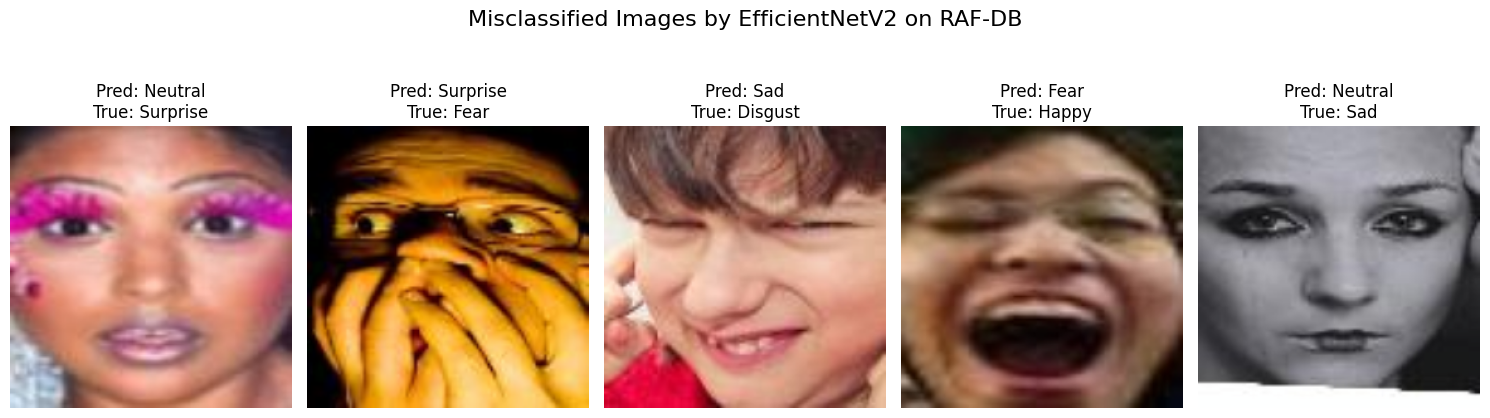

In [19]:
# Plot misclassified images for EfficientNetV2
plot_misclassified_images(efficientnet, test_dataset, num_images=5)